In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer, StandardScaler
import os
import json
import numpy as np

In [35]:
ace = pd.read_pickle("/mnt/disks/data/ACE/ace_full.pkl")
dscovr = pd.read_pickle("/mnt/disks/data/DSCOVR/dscovr_full.pkl")

In [36]:
dscovr_mapping = pd.read_csv("/mnt/disks/data/DSCOVR/dscovr_mapping_train_full.csv")
ace_mapping = pd.read_csv("/mnt/disks/data/ACE/ace_mapping_train_full.csv")

In [41]:
ace_mapped = ace.loc[ace_mapping["Time"]]
dscovr_mapped = dscovr.loc[dscovr_mapping["Time"]]
ace_mapped["Time"] = ace_mapped.index
dscovr_mapped["Time"] = dscovr_mapped.index

In [42]:
full_data = pd.concat([ace_mapped, dscovr_mapped], axis=0, ignore_index=True)

In [43]:
full_data

,bx,by,bz,bt,v,n,t,dipole_tilt,f107,kp,...,derived_7,derived_8,derived_9,derived_10,derived_11,derived_12,derived_13,p,e,Time
0,0.70,-3.00,1.30,3.30,361.600000,1.80,94900.0,12.348327,169.5,0.667,...,-11.330277,-11.945855,-2.256595,-247.268101,-2.407858,-263.842844,0.841908,0.470716,-0.470080,2001-08-11 16:57:00
1,1.10,-2.60,1.30,3.10,354.800000,2.20,140000.0,12.348327,169.5,0.667,...,-11.044680,-11.644741,-1.860000,-212.880000,-2.480000,-283.840000,0.800000,0.553885,-0.461240,2001-08-11 16:58:00
2,1.10,-2.60,1.30,3.10,354.500000,2.20,135000.0,12.348327,169.5,0.667,...,-11.044680,-11.644741,-1.860000,-212.700000,-2.480000,-283.600000,0.800000,0.552949,-0.460850,2001-08-11 16:59:00
3,1.20,-2.80,1.00,3.20,355.800000,1.60,156000.0,12.348327,169.5,0.667,...,-11.628937,-12.260742,-2.476018,-275.302262,-2.027149,-225.393665,0.886878,0.405100,-0.355800,2001-08-11 17:00:00
4,0.80,-3.10,0.70,3.30,360.700000,1.50,108000.0,12.348327,169.5,0.667,...,-12.045065,-12.699478,-2.979802,-325.701386,-1.418020,-154.993861,0.951485,0.390313,-0.252490,2001-08-11 17:02:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2204054,1.27,-6.83,-1.91,7.21,365.700012,10.38,40642.0,18.722439,184.5,4.333,...,-18.030680,-13.081208,-6.164102,-312.650757,3.740047,189.699753,0.927469,2.776370,0.698487,2024-05-31 05:59:00
2204055,0.31,-5.54,-2.75,6.20,362.899994,14.23,47402.0,18.722439,184.5,2.333,...,-16.770004,-12.166592,-3.748627,-219.415619,4.938400,289.055695,0.802309,3.748080,0.997975,2024-05-31 06:00:00
2204056,0.31,-5.54,-2.75,6.20,362.899994,14.23,47402.0,18.722439,184.5,2.333,...,-16.770004,-12.166592,-3.748627,-219.415619,4.938400,289.055695,0.802309,3.748080,0.997975,2024-05-31 06:01:00
2204057,0.48,-5.63,-2.38,6.14,364.299988,13.40,41437.0,18.722439,184.5,2.333,...,-17.244866,-12.511103,-4.278212,-253.835907,4.404146,261.307892,0.848389,3.556748,0.867034,2024-05-31 06:02:00


[  2.   1.   1.   1.   2.   4.  11.  34. 100.]


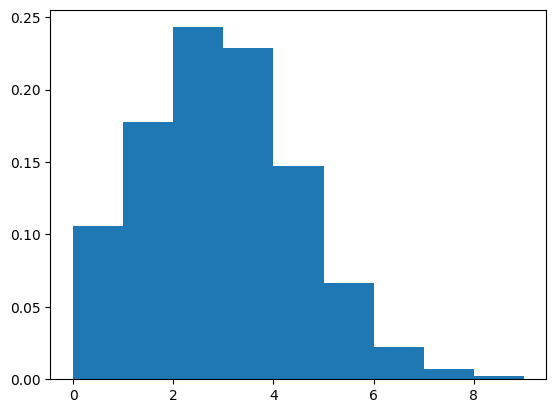

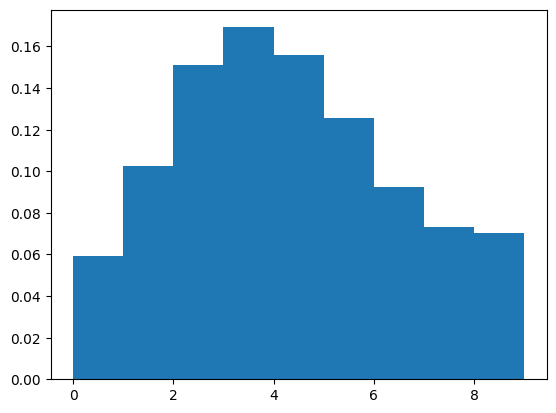

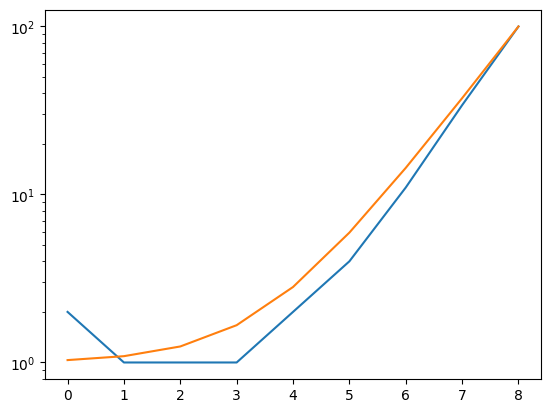

In [69]:
plt.figure()
plt.hist(full_data.kp, bins=range(0, 10), density=True)

# find the weighting of each time step in full_data, such that the distribution of kp is uniform given bins between 0 and 9
# this is done by finding the number of time steps in each bin, and then dividing by the total number of time steps
# the weighting is then 1/(number of time steps in bin)

# find the number of time steps in each bin
counts, bins = np.histogram(full_data.kp, bins=range(0, 10, 1))
# find the weighting of each bin
weights = 1 / counts
# find relative scaling needed
weights = np.round(weights / min(weights), 0)
# weights = weights/min(weights)
# find the weight of each time step, i.e., if timestep is within bin range
weighting = np.zeros(len(full_data))
for i in range(0, 9, 1):
    weighting += ((full_data.kp > bins[i]) & (full_data.kp <= bins[i + 1])) * weights[i]

print(weights)

weighting = 1 + 99 * (np.exp(full_data.kp) / np.exp(9))

plt.figure()
plt.hist(full_data.kp, bins=range(0, 10), weights=weighting, density=True)

plt.figure()
x = np.arange(9)
y = np.exp(x) / np.exp(x[-1])
# plt.plot(x,y*100)
plt.plot(weights)
plt.plot(x, 1 + y * 99)
plt.yscale("log")

In [ ]:
pt = PowerTransformer(method="yeo-johnson", standardize=True)

In [ ]:
full_data_scaler = pt.fit(full_data)

In [ ]:
def save_scaler(scaler, scaler_dir, filename):
    """
    Saves a PowerTransfomer(method='yeo-johnson', standardize=True) object to a JSON file.

    Args:
        scaler (PowerTransfomer): The scaler object to save.
        filename (str): Name of the JSON file to save the scaler.
    """
    pt_scaler_dict = {
        "params": scaler.get_params(),
        "lambdas": scaler.lambdas_.tolist(),
        "n_features": scaler.n_features_in_,
        "feature_names": scaler.feature_names_in_.tolist(),
    }
    std_scaler_dict = {
        "mean": scaler._scaler.mean_.tolist(),
        "scale": scaler._scaler.scale_.tolist(),
        "var": scaler._scaler.var_.tolist(),
    }
    with open(os.path.join(scaler_dir, "pt_" + filename), "w") as f:
        json.dump(pt_scaler_dict, f)

    with open(os.path.join(scaler_dir, "std_" + filename), "w") as f:
        json.dump(std_scaler_dict, f)

In [ ]:
def load_pt_scaler(scaler_dir, filename):
    """
    Loads a PowerTransformer and associated StandardScaler object from JSON files.

    Args:
        filename (str): Name of the JSON file containing the scaler.

    Returns:
        PowerTransformer: The loaded scaler object.
    """
    with open(os.path.join(scaler_dir, "pt_" + filename), "r") as f:
        pt_scaler_dict = json.load(f)
    pt_scaler = PowerTransformer(method="yeo-johnson", standardize=False)
    for key, value in pt_scaler_dict["params"].items():
        pt_scaler.set_params(**{key: value})
    pt_scaler.lambdas_ = np.array(pt_scaler_dict["lambdas"])
    pt_scaler.n_features_in_ = pt_scaler_dict["n_features"]
    pt_scaler.feature_names_in_ = np.array(pt_scaler_dict["feature_names"])

    with open(os.path.join(scaler_dir, "std_" + filename), "r") as f:
        std_scaler_dict = json.load(f)
    std_scaler = StandardScaler()
    std_scaler.mean_ = np.array(std_scaler_dict["mean"])
    std_scaler.scale_ = np.array(std_scaler_dict["scale"])
    std_scaler.var_ = np.array(std_scaler_dict["var"])

    return pt_scaler, std_scaler

In [ ]:
save_scaler(pt, ".", "scaler.json")

# apply the scaler to the data - note the double step to include the standardization from the original fit
pt_tst, std_tst = load_pt_scaler(".", "scaler.json")
pt_tst._scaler = std_tst
pt_tst.set_output(transform="pandas")

In [ ]:
full_data_fitted = pt_tst.transform(full_data)

In [ ]:
# plot the transformed data

for col in full_data_fitted.columns:
    plt.hist(full_data_fitted[col], bins=100)
    plt.title(col)
    plt.show()

In [ ]:
full_data_inv = pt_tst.inverse_transform(full_data_fitted)

In [ ]:
# plot distributions of all collumns in full_data_scaler
full_data_scaler_df = pd.DataFrame(full_data_inv, columns=full_data.columns)

for col in full_data_scaler_df.columns:
    plt.figure()
    full_data_scaler_df[col].plot.hist(bins=100)
    full_data[col].plot.hist(bins=100, alpha=0.5)
    plt.title(col)
    plt.show()